# STAT 7220 - Homework 4
## Mixed Effects Experiments
## Dr. Austin Brown
## Due Date: April 24, 2026

## Instructions:

The International Paralympic Committee is evaluating two new carbon-fiber blade designs: Model A (Aerostep) and Model B (Bionic-Flex). The goal is to determine if either new design yields meaningfully different 100-meter sprint times among T64 sprinters. Note, a T64 sprinter is an athlete with an absence of one leg below the knee.

Because sprint performance is highly dependent on an individual athlete’s biomechanics, muscle composition, and training level, the research team has recruited 5 professional T64 sprinters to participate in a study. Each athlete will perform three timed trials with both of the blade types in a randomized order. In this experiment, we want to control for the variability of individual athletes, but we are most interested in comparing the mean differences between the two blade designs. The results of this experiment are contained in the `Paralympic_Blade_Experiment.xlsx` file. With these data, I want you to:

1.  Briefly describe the objective of the experiment.

The objective of this experiment is to determine whether the two carbon-fiber blade designs, Aerostep and Bionic-Flex, produce different mean 100-meter sprint times among T64 sprinters while accounting for differences between individual athletes.

2.  Specify the outcome variable and how it is measured.

The outcome variable is a **quantitative, continuous variable** representing the 100-meter sprint time. It is measured in **seconds**, where lower values indicate faster sprint performance.

3.  Specify the independent variables, including which is fixed and which is random. What lurking variables may be present?

The independent variables are:

- **Blade Type** = fixed effect  
  - Aerostep  
  - Bionic-Flex  

- **Athlete_ID** = random effect  
  - 5 professional T64 sprinters  

Possible lurking variables include:

- athlete fatigue level during a trial  
- day-to-day variation in performance  
- warm-up quality  
- track or surface conditions  
- weather or temperature  
- athlete motivation or focus  
- slight timing error  
- prior familiarity or comfort with a blade design

4.  Explain the difference between a random effect and a fixed effect. Why should we account for random effects in our designs?

A **fixed effect** is a factor whose specific levels are of direct interest in the study. In this experiment, blade type is a fixed effect because the goal is to compare the mean sprint times for Aerostep and Bionic-Flex.

A **random effect** is a factor whose levels are viewed as a sample from a larger population, and the goal is to account for the variability associated with those levels rather than compare them directly. In this experiment, athlete is a random effect because the 5 sprinters represent a sample of possible T64 athletes, and we want to control for natural differences among athletes.

We should account for random effects because sprint performance can vary substantially across athletes due to biomechanics, strength, and training level. If we ignore this athlete-to-athlete variability, we may incorrectly attribute some of that variation to the blade designs.

5.  State the sets of null and alternative hypotheses for this experiment.

Let

- $\mu_A$ = mean sprint time for Aerostep  
- $\mu_B$ = mean sprint time for Bionic-Flex  

For the fixed effect of blade type:

$$
H_0: \mu_A = \mu_B
$$

$$
H_A: \mu_A \ne \mu_B
$$

This tests whether the two blade designs have the same mean sprint time.

For the random effect of athlete:

$$
H_0: \sigma^2_{\text{athlete}} = 0
$$

$$
H_A: \sigma^2_{\text{athlete}} > 0
$$

This tests whether there is meaningful variability in sprint times across athletes.

6.  Perform appropriate exploratory analysis, including data visualizations. Do the results of these analyses support the null or alternative hypotheses more strongly?

In [5]:
## Question 6 Code ##
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
df = pd.read_excel("STAT Paralympic_Blade_Experiment.xlsx")

# Check structure
print(df.head())
df.info()

# Overall summary
print("\nOverall summary")
print(df["Sprint_Time"].describe())

# Summary by blade type
print("\nSummary by blade type")
print(df.groupby("Blade_Type")["Sprint_Time"].describe())

# Summary by athlete and blade type
print("\nSummary by athlete and blade type")
print(df.groupby(["Athlete_ID", "Blade_Type"])["Sprint_Time"].describe())

# Mean by athlete and blade type
print("\nMean sprint time by athlete and blade type")
print(df.groupby(["Athlete_ID", "Blade_Type"])["Sprint_Time"].mean())

  Athlete_ID   Blade_Type  Trial  Sprint_Time
0  Athlete_1     Aerostep      1        11.63
1  Athlete_1     Aerostep      2        11.57
2  Athlete_1     Aerostep      3        11.39
3  Athlete_1  Bionic-Flex      1        11.74
4  Athlete_1  Bionic-Flex      2        11.68
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Athlete_ID   30 non-null     object 
 1   Blade_Type   30 non-null     object 
 2   Trial        30 non-null     int64  
 3   Sprint_Time  30 non-null     float64
dtypes: float64(1), int64(1), object(2)
memory usage: 1.1+ KB

Overall summary
count    30.000000
mean     11.336000
std       0.208055
min      10.940000
25%      11.232500
50%      11.350000
75%      11.417500
max      11.740000
Name: Sprint_Time, dtype: float64

Summary by blade type
             count    mean       std    min     25%    50%     75%    max
Blade_Ty

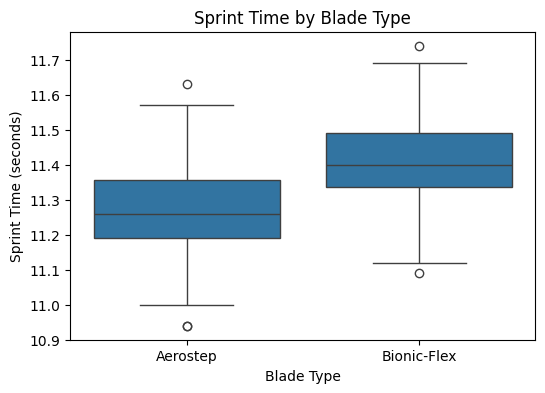

In [2]:
# Boxplot by blade type
plt.figure(figsize=(6,4))
sns.boxplot(x="Blade_Type", y="Sprint_Time", data=df)
plt.title("Sprint Time by Blade Type")
plt.xlabel("Blade Type")
plt.ylabel("Sprint Time (seconds)")
plt.show()

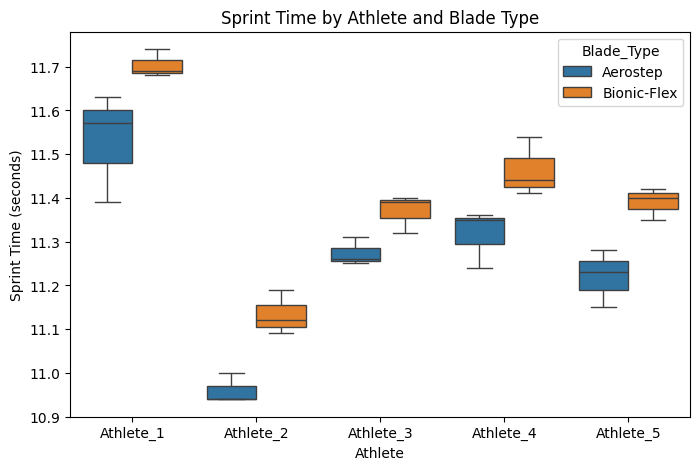

In [3]:
# Boxplot by athlete with hue for blade type
plt.figure(figsize=(8,5))
sns.boxplot(x="Athlete_ID", y="Sprint_Time", hue="Blade_Type", data=df)
plt.title("Sprint Time by Athlete and Blade Type")
plt.xlabel("Athlete")
plt.ylabel("Sprint Time (seconds)")
plt.show()

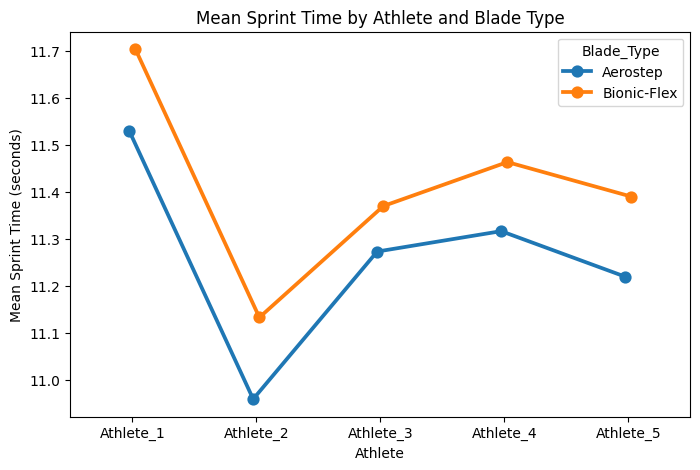

In [4]:
# Point plot of athlete means by blade type
plt.figure(figsize=(8,5))
sns.pointplot(x="Athlete_ID", y="Sprint_Time", hue="Blade_Type", data=df, dodge=True, errorbar=None)
plt.title("Mean Sprint Time by Athlete and Blade Type")
plt.xlabel("Athlete")
plt.ylabel("Mean Sprint Time (seconds)")
plt.show()

Exploratory analysis was performed using summary statistics, boxplots, and mean plots to examine how sprint times vary across blade types and athletes.

The overall mean sprint time is approximately 11.34 seconds, with relatively small variability across observations. When comparing blade types, the mean sprint time for **Aerostep** is 11.26 seconds, while the mean for **Bionic-Flex** is 11.41 seconds. This indicates that Aerostep generally results in faster sprint times (lower values).

The boxplot of sprint time by blade type shows that the distribution for Aerostep is shifted lower than that of Bionic-Flex, with a lower median. Although there is some overlap between the two distributions, the central tendency is clearly lower for Aerostep, suggesting better performance.

The grouped boxplots by athlete provide stronger evidence. For **every athlete**, the sprint times under Aerostep are lower than those under Bionic-Flex. This consistent pattern across all five athletes indicates that the effect of blade type is not driven by a single individual but is present across all participants.

The mean plot further confirms this result. The mean sprint time for Aerostep is lower than Bionic-Flex for each athlete, and the lines do not cross. The lines are also roughly parallel, suggesting that the difference between blade types is fairly consistent across athletes.

At the same time, the plots show clear differences in sprint times across athletes. For example, some athletes consistently run faster than others regardless of blade type. This indicates substantial variability between athletes, supporting the need to treat athlete as a **random effect** in the analysis.

Overall, the exploratory analysis suggests that sprint times differ between blade types, with Aerostep consistently producing faster times. These results provide support for the **alternative hypothesis**, while also highlighting the importance of accounting for variability between athletes.

7. Fit the mixed effects model. Using the model residuals, check the assumption of normality using both a testing method and a visual method. Do we have support for the assumption of normality from the data? Why or why not?

                Mixed Linear Model Regression Results
Model:                MixedLM     Dependent Variable:     Sprint_Time
No. Observations:     30          Method:                 REML       
No. Groups:           5           Scale:                  0.0034     
Min. group size:      6           Log-Likelihood:         28.3941    
Max. group size:      6           Converged:              Yes        
Mean group size:      6.0                                            
---------------------------------------------------------------------
                          Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------------------
Intercept                 11.260    0.092 122.543 0.000 11.080 11.440
Blade_Type[T.Bionic-Flex]  0.152    0.021   7.095 0.000  0.110  0.194
Group Var                  0.041    0.542                            



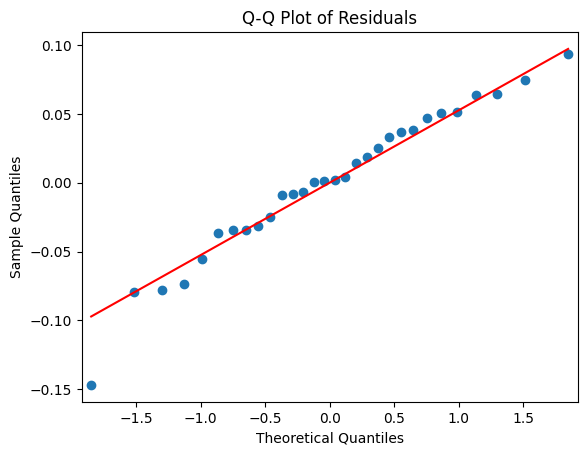

Shapiro-Wilk Statistic: 0.9701104027768613
p-value: 0.5422004847170765
Fail to reject H0: Residuals are approximately normal


In [7]:
## Question 7 Code ##
import statsmodels.api as sm
from statsmodels.formula.api import mixedlm
import scipy.stats as stats
import matplotlib.pyplot as plt

# Fit mixed effects model
model = mixedlm(
    "Sprint_Time ~ Blade_Type",   # fixed effect
    data=df,
    groups=df["Athlete_ID"]      # random effect
).fit()

print(model.summary())

# Extract residuals
residuals = model.resid

# -------------------------
# Q-Q Plot (visual check)
# -------------------------
sm.qqplot(residuals, line='s')
plt.title("Q-Q Plot of Residuals")
plt.show()

# -------------------------
# Shapiro-Wilk Test
# -------------------------
sw = stats.shapiro(residuals)
print(f"Shapiro-Wilk Statistic: {sw[0]}")
print(f"p-value: {sw[1]}")

if sw[1] < 0.05:
    print("Reject H0: Residuals are not normal")
else:
    print("Fail to reject H0: Residuals are approximately normal")

A mixed effects model was fit to the data with blade type as a fixed effect and athlete as a random effect.

The normality assumption was assessed using both a Q-Q plot of the residuals and the Shapiro–Wilk test.

From the Q-Q plot, most of the residuals lie close to the reference line, suggesting that the residuals are approximately normally distributed. There is one noticeable point in the lower tail that deviates more from the line than the others, but the rest of the points follow the line fairly well and there is no strong systematic curvature.

The Shapiro–Wilk test provides a formal assessment of normality. The p-value is 0.542, which is greater than 0.05. Therefore, we fail to reject the null hypothesis of normality, indicating that there is no strong statistical evidence against the assumption that the residuals are normally distributed.

Overall, although the Q-Q plot shows a mild deviation in the lower tail, both the visual and testing methods suggest that the normality assumption is reasonably satisfied for this mixed effects model.

8. **Using the visual method described in the lecture notes**, check the assumption of constant variance. Do we have support for the assumption of constant variance? Why or why not?

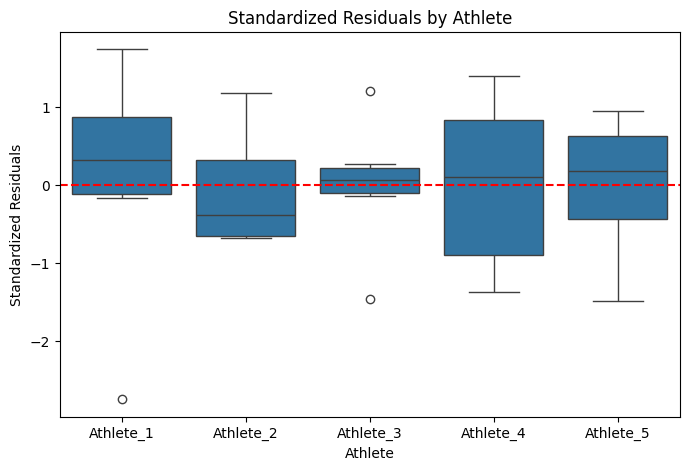

In [8]:
## Question 8 Code ##
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# residuals from mixed model
residuals = model.resid

# standardized residuals
standardized_residuals = (residuals - np.mean(residuals)) / np.std(residuals, ddof=1)

# boxplot of standardized residuals by athlete
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Athlete_ID"], y=standardized_residuals)
plt.axhline(0, linestyle="--", color="red")
plt.xlabel("Athlete")
plt.ylabel("Standardized Residuals")
plt.title("Standardized Residuals by Athlete")
plt.show()

In [9]:
from statsmodels.stats.diagnostic import het_breuschpagan

# residuals from mixed model
residuals = model.resid

# use the fixed-effects design matrix from the fitted model
bp_test = het_breuschpagan(residuals, model.model.exog)

# Extract statistic and p-value
bp_stat = bp_test[0]
bp_pvalue = bp_test[1]

print("Breusch-Pagan Test Statistic:", bp_stat)
print("p-value:", bp_pvalue)

Breusch-Pagan Test Statistic: 1.7475144840695278
p-value: 0.18618950167510886


The constant variance assumption was assessed using both a visual method and the Breusch–Pagan test.

The visual method used was a boxplot of standardized residuals by athlete. From this plot, the residuals are centered around zero for each athlete, and the spread of the residuals appears reasonably similar across groups. Although there are some minor differences in spread and a few extreme values, no athlete shows a substantially larger or smaller variability than the others.

The Breusch–Pagan test provides a formal assessment of constant variance. The p-value is 0.186, which is greater than 0.05. Therefore, we fail to reject the null hypothesis of constant variance, indicating that there is no strong statistical evidence of heteroscedasticity.

Overall, both the visual and testing methods suggest that the assumption of constant variance is reasonably satisfied for this mixed effects model.

9. Report and interpret the result of the random effect. Which of the two hypotheses for the random effect are more strongly supported by the data?

In [10]:
## Question 9 Code ##
import statsmodels.api as sm
from statsmodels.formula.api import mixedlm, ols
from scipy.stats import chi2

# Full model: with random effect for athlete
full_model = mixedlm(
    "Sprint_Time ~ Blade_Type",
    data=df,
    groups=df["Athlete_ID"]
).fit()

# Reduced model: no random effect
reduced_model = ols(
    "Sprint_Time ~ Blade_Type",
    data=df
).fit()

# Likelihood ratio test
lr_stat = 2 * (full_model.llf - reduced_model.llf)
p_value = chi2.sf(lr_stat, df=1)

print("Full model log-likelihood:", full_model.llf)
print("Reduced model log-likelihood:", reduced_model.llf)
print("Likelihood Ratio Statistic:", lr_stat)
print("p-value:", p_value)

# Random effect variance estimate
print("Random effect variance (Athlete):")
print(full_model.cov_re)

Full model log-likelihood: 28.394107855299097
Reduced model log-likelihood: 7.267082504026941
Likelihood Ratio Statistic: 42.25405070254431
p-value: 8.015382125122537e-11
Random effect variance (Athlete):
          Group
Group  0.041068


The random effect in this model represents the variability in sprint times across athletes. To assess whether the random effect is needed, the full mixed effects model was compared to a reduced model without the random athlete effect using a likelihood ratio test.

The estimated variance of the random effect for athlete was **0.0411**, which indicates that sprint times vary across athletes.

The likelihood ratio test produced a statistic of **42.254** with a p-value of **8.02 × 10⁻¹¹**. Since this p-value is much smaller than 0.05, we reject the null hypothesis that the athlete-level variance is zero.

Therefore, the data more strongly support the **alternative hypothesis** for the random effect. This means that there is strong evidence of meaningful variability in sprint times across athletes, so accounting for athlete as a random effect is appropriate.

10. Report and interpret the result of the fixed effect. Which of the two hypotheses for the fixed effect are more strongly supported by the data?

In [11]:
## Question 10 Code ##
# Fixed effect estimate, z-statistic, and p-value for blade type
coef = model.params["Blade_Type[T.Bionic-Flex]"]
z_value = model.tvalues["Blade_Type[T.Bionic-Flex]"]
p_value = model.pvalues["Blade_Type[T.Bionic-Flex]"]

print("Fixed effect estimate (Bionic-Flex vs Aerostep):", coef)
print("z-value:", z_value)
print("p-value:", p_value)

Fixed effect estimate (Bionic-Flex vs Aerostep): 0.15199999999999983
z-value: 7.094735330712243
p-value: 1.2959926827147746e-12


The fixed effect in this model is **blade type**. From the mixed effects model, the estimated coefficient for **Bionic-Flex** is **0.152**, with a z-value of **7.095** and a p-value of **1.30 × 10⁻¹²**.

This result indicates that, after accounting for variability across athletes, the **Bionic-Flex** blade is associated with sprint times that are about **0.152 seconds slower** on average compared to the **Aerostep** blade. Since lower sprint times indicate better performance, this suggests that **Aerostep performs better than Bionic-Flex**.

For the fixed effect of blade type, the hypotheses are:

$$
H_0: \mu_A = \mu_B
$$

$$
H_A: \mu_A \ne \mu_B
$$

Because the p-value is much smaller than 0.05, we reject the null hypothesis and conclude that the data more strongly support the **alternative hypothesis**. This provides strong evidence that the two blade designs produce different mean sprint times.

11. Finally, provide a brief contextual conclusion for this experiment. Discuss experiment limitations and future directions.

The results of this experiment show that blade type has a clear effect on 100-meter sprint performance for T64 athletes. After accounting for differences between athletes using a mixed effects model, the **Aerostep** blade consistently produced faster sprint times compared to the **Bionic-Flex** blade. On average, Bionic-Flex resulted in sprint times that were about 0.152 seconds slower, which suggests that Aerostep performs better overall.

The results also showed that there is meaningful variation between athletes. This means that individual differences, such as strength, technique, or biomechanics, have a real impact on performance. Because of this, it was important to treat athlete as a random effect in the model.

There are a few limitations to this study. The sample size is small, with only five athletes, so the results may not fully represent all T64 sprinters. The experiment was also conducted under controlled conditions, which may be different from real race situations. Other factors like fatigue, training routines, and how comfortable an athlete is with each blade could also affect the results.

For future research, it would be useful to include more athletes and collect data over a longer period of time. This would help see if the results stay consistent and allow athletes to fully adapt to each blade. It may also be helpful to look at other performance measures, such as acceleration or endurance, for a more complete comparison.

Overall, the results suggest that the Aerostep blade provides a performance advantage, while also showing that differences between athletes play an important role in sprint performance.